<table class="table table-bordered">
    <tr>
        <th style="text-align:center; width:25%"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 250px; height: 125px; "></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment 1 - Food Classification Model (Individual)</h2><h3>AY2020/21 Semester</h3></th>
    </tr>
</table>

In [1]:
!git clone https://github.com/FLaries/notebooks.git

Cloning into 'notebooks'...
remote: Enumerating objects: 10043, done.
remote: Total 10043 (delta 0), reused 0 (delta 0), pack-reused 10043
Receiving objects: 100% (10043/10043), 481.94 MiB | 39.88 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Checking out files: 100% (10002/10002), done.


In [48]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


In [2]:
# Import the Required Packages
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
from keras.regularizers import l2
from keras.regularizers import l1
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import ResNet50

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:95% !important; }</style>"))

Using TensorFlow backend.


In [0]:
# Graph plotting function
def plot_graph(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

## Step 1: Data Loading

In [85]:
base_dir = '/content/notebooks/DL_Assignment/images'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

img_size = 150

train_datagen = ImageDataGenerator(
      rescale=1./255,
      horizontal_flip=True,
      rotation_range=10,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2)
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(img_size, img_size),
        batch_size=20)

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(img_size, img_size),
        batch_size=20)

Found 7500 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.


## Step 2:  Develop the Image Classification Models

### Model #1

In [0]:
# Build the Model
model1 = models.Sequential()
model1.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(img_size, img_size, 3)))
model1.add(layers.Conv2D(32, (3, 3), activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Dropout(0.5))
model1.add(layers.Flatten())
model1.add(layers.Dense(256, activation='relu'))
model1.add(layers.Dense(10, activation='softmax'))

# model1.summary()

In [87]:
# Train the Model
model1.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])

history1 = model1.fit_generator(
      train_generator,
      steps_per_epoch=375,
      epochs=20,
      validation_data=validation_generator,
      validation_steps=100)

Epoch 1/20
375/375 [==============================] - 78s 209ms/step - loss: 2.2067 - acc: 0.2199 - val_loss: 1.9647 - val_acc: 0.3120
Epoch 2/20
375/375 [==============================] - 78s 209ms/step - loss: 1.9901 - acc: 0.2983 - val_loss: 1.9461 - val_acc: 0.3350
Epoch 3/20
375/375 [==============================] - 79s 210ms/step - loss: 1.8509 - acc: 0.3508 - val_loss: 1.6409 - val_acc: 0.4315
Epoch 4/20
375/375 [==============================] - 79s 210ms/step - loss: 1.7665 - acc: 0.3963 - val_loss: 1.6329 - val_acc: 0.4590
Epoch 5/20
375/375 [==============================] - 78s 209ms/step - loss: 1.7119 - acc: 0.4088 - val_loss: 1.5583 - val_acc: 0.4695
Epoch 6/20
375/375 [==============================] - 78s 209ms/step - loss: 1.6753 - acc: 0.4299 - val_loss: 1.8631 - val_acc: 0.4140
Epoch 7/20
375/375 [==============================] - 79s 211ms/step - loss: 1.6185 - acc: 0.4468 - val_loss: 1.5569 - val_acc: 0.4870
Epoch 8/20
375/375 [==============================] - 7

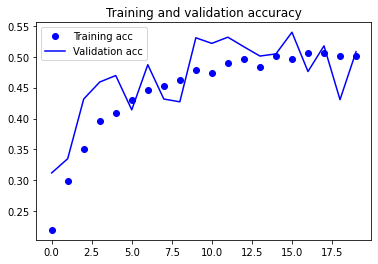

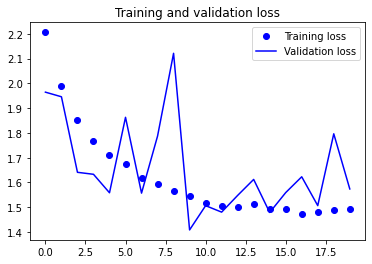

In [88]:
# Plot the Training and Validation Accuracy & Loss Scores
plot_graph(history1)

In [0]:
# Save the Model
path = '/content/gdrive/My Drive/DL/Assg/chkpoints/'
model1.save(path+'food_model_1.h5')

### Model #2

In [0]:
img_size = 150

conv_base = ResNet50(weights='imagenet',
                  include_top=False,
                  input_shape=(img_size, img_size, 3))
conv_base.trainable = True
set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'conv3_block1_1_conv':
        set_trainable = True # after black5_conv1, set_trainable becomes True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False
# conv_base.summary()

In [43]:
base_dir = '/content/notebooks/DL_Assignment/images'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
      rescale=1./255,
      horizontal_flip=True,
      rotation_range=10,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(img_size, img_size),
        batch_size=20)

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(img_size, img_size),
        batch_size=20)

Found 7500 images belonging to 10 classes.
Found 2000 images belonging to 10 classes.


In [44]:
# Build the Model
model2 = models.Sequential()
model2.add(conv_base)
model2.add(layers.Flatten())
# model2.add(layers.Dropout(0.5))
model2.add(layers.Dense(256, activation='relu', kernel_regularizer=l2(0.005)))
model2.add(layers.Dense(10, activation='softmax'))
model2.summary()

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Model)             (None, 5, 5, 2048)        23587712  
_________________________________________________________________
flatten_8 (Flatten)          (None, 51200)             0         
_________________________________________________________________
dense_16 (Dense)             (None, 256)               13107456  
_________________________________________________________________
dense_17 (Dense)             (None, 10)                2570      
Total params: 36,697,738
Trainable params: 36,417,802
Non-trainable params: 279,936
_________________________________________________________________


In [45]:
# Train the Model
model2.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(lr=2e-5),
              metrics=['acc'])

history2 = model2.fit_generator(
      train_generator,
      steps_per_epoch=375,
      epochs=20,
      validation_data=validation_generator,
      validation_steps=100,
      verbose=1)

Epoch 1/20
375/375 [==============================] - 92s 245ms/step - loss: 4.4048 - acc: 0.3344 - val_loss: 4.6523 - val_acc: 0.2460
Epoch 2/20
375/375 [==============================] - 90s 239ms/step - loss: 3.3783 - acc: 0.5031 - val_loss: 3.2444 - val_acc: 0.5140
Epoch 3/20
375/375 [==============================] - 88s 235ms/step - loss: 2.7682 - acc: 0.5755 - val_loss: 2.5790 - val_acc: 0.6070
Epoch 4/20
375/375 [==============================] - 89s 236ms/step - loss: 2.3642 - acc: 0.6173 - val_loss: 2.3742 - val_acc: 0.6295
Epoch 5/20
375/375 [==============================] - 88s 235ms/step - loss: 2.0821 - acc: 0.6572 - val_loss: 2.2104 - val_acc: 0.6350
Epoch 6/20
375/375 [==============================] - 88s 234ms/step - loss: 1.8551 - acc: 0.6815 - val_loss: 2.4544 - val_acc: 0.6290
Epoch 7/20
375/375 [==============================] - 86s 231ms/step - loss: 1.6429 - acc: 0.7129 - val_loss: 2.2126 - val_acc: 0.6830
Epoch 8/20
375/375 [==============================] - 8

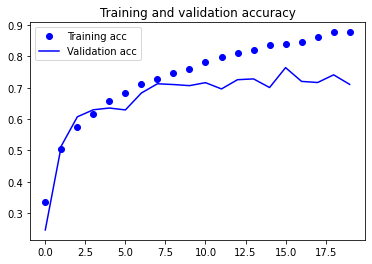

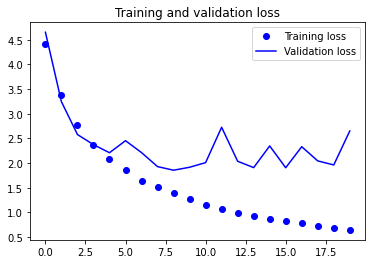

In [46]:
# Plot the Training and Validation Accuracy & Loss Scores
plot_graph(history2)

In [0]:
# Save the Model
path = '/content/gdrive/My Drive/DL/Assg/chkpoints/'
model2.save(path+'food_model_2.h5')

## Step 3 – Evaluate the Developed Models using Testing Images

In [0]:
# Model #1
model.load_weights('food_model_1.h5')




In [0]:
# Model #2
model.load_weights('food_model_2.h5')




In [0]:
# Save the best model


model.save('food_model_best.h5')

## Step 4  – Use the best model to make prediction

In [0]:
# Load the model
model.load_weights('food_model_best.h5')

In [0]:
# Load the food list (in alphabetical order)
with open('??.txt', 'r') as f: # the .txt file which contains a list of food assigned to you
    x = f.readlines()
food_list =[]
for item in x:
    food_list.append(item.strip('\n'))
food_list = sorted(food_list) # food_list needs to be sorted alphabetically before feed into prediction() function
print(food_list)

In [0]:
# Define some related functions for image process and model prediction
from keras.preprocessing.image import load_img, img_to_array
def image_process(img):
    image = load_img(img, target_size =(img_size, img_size))
    image_array = img_to_array(image)/255
    return image_array

import pandas as pd
def prediction(model, img_array, items_l):
    prob = model.predict(img_array.reshape(1,img_size,img_size,3))
    pro_df = pd.DataFrame(prob, columns = items_l)
    result = items_l[np.argmax(prob)]
    return pro_df, result

In [0]:
# Make prediction for the image you downloaded from internet
import matplotlib.pyplot as plt
img = '??.jpeg' # the picture you downloaded from internet, which contains a type of food in your food list
plt.imshow(plt.imread(img))
plt.show()

img_array = image_process(img)
prob_df, result = prediction(model, img_array, food_list)
print('The prediction is: ', result, '\n\n', prob_df)